# spMosaic Tutorial Example 1: Integrating Samples from Visium_DLPFC Donor1

### I. Input data overview

The Visium_DLPFC dataset contains 12 samples from 3 donors, with 4 samples from each donor. In this tutorial, we demonstrate how to use spMosaic to integrate the four samples from Donor1.

We start with an `.h5ad` file as the input to the spMosaic pipeline. The input `.h5ad` file should satisfy the following requirements:

- The gene expression matrix should be stored in the `.X` slot as a `scipy` sparse matrix. All spots from all samples should be included. For this dataset, `.X` contains raw count data.
- Spot-level metadata should be stored in the `.obs` slot as a pandas `DataFrame`. The `.obs` table must contain the following information:
  - `sample_name`: the sample label for each spot. This can be either a string or an integer.
  - `row` and `col`: the spatial coordinates for each spot.
  - The `.obs` index should contain the spot barcodes, and the index name should be exactly `barcode`.

The `.obs` table may contain additional metadata columns, but they are not required for running spMosaic.

The `.h5ad` file used in this tutorial can be downloaded from this [link](https://www.dropbox.com/scl/fo/c2fonb4sbeiu9ddrtlm87/ALQAjA_jman3udZRRjD32Ow?rlkey=acn3m5dwbj6ce6ipjex3fadbk&st=y6e8m7dm&dl=0).

In [1]:
import sys
import os
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from spmosaic import gene_smooth, domain_detection, get_rscript_path

# set working directory
os.chdir("/path/to/spMosaic_example_data")
# input data for Donor1
Donor1_h5ad = sc.read_h5ad("Visium_DLPFC/Visium_DLPFC_Donor1.h5ad")

The code above sets the working directory and loads the input `.h5ad` file. The `Donor1_h5ad` object stores the input data needed for the spMosaic pipeline. In addition to the required columns described above, the metadata contains additional information, including:

- `domain_guess`: the annotated spatial domain label for each spot.

In [2]:
Donor1_h5ad.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 24323514 stored elements and shape (17985, 33538)>

In [3]:
Donor1_h5ad.obs.head()

,sample_name,row,col,domain_guess
barcode,,,,
151507_AAACAACGAATAGTTC-1,151507,0,16,Layer1
151507_AAACAAGTATCTCCCA-1,151507,50,102,Layer3
151507_AAACAATCTACTAGCA-1,151507,3,43,Layer1
151507_AAACACCAATAACTGC-1,151507,59,19,WM
151507_AAACAGCTTTCAGAAG-1,151507,43,9,Layer6


Next, we visualize the **annotated** spatial domains for each sample using the spot coordinates.

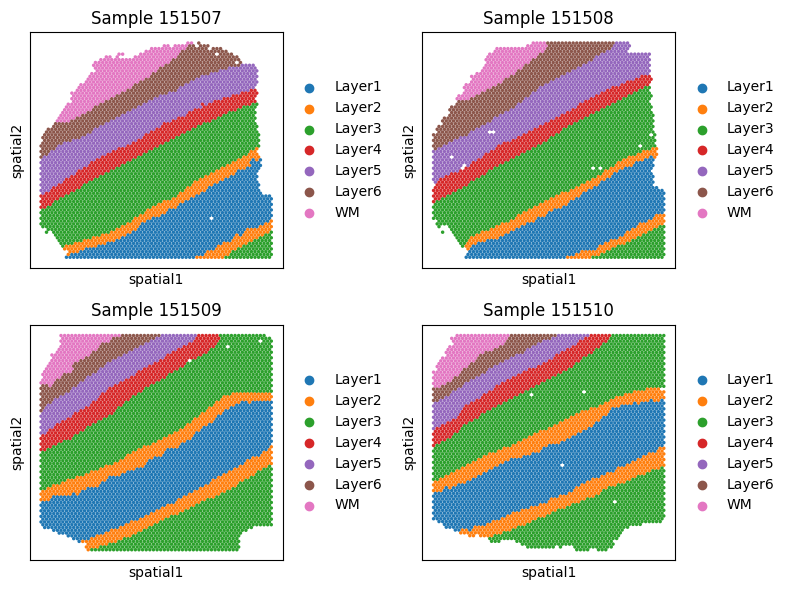

In [4]:
Donor1_h5ad.obsm["spatial"] = Donor1_h5ad.obs[["col", "row"]].to_numpy()

samples = Donor1_h5ad.obs["sample_name"].unique()

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for sample, ax in zip(samples, axes.flatten()):
    adata_sub = Donor1_h5ad[Donor1_h5ad.obs["sample_name"] == sample].copy()

    sc.pl.embedding(
        adata_sub,
        basis="spatial",
        color="domain_guess",
        size=25,
        ax=ax,
        show=False,
        title=f"Sample {sample}"
    )

plt.tight_layout()
plt.show()

### II. Stage 1: spatial smoothing

The spMosaic pipeline consists of two stages. In Stage 1, we fit a generalized additive model (GAM) to each gene within each sample. This step identifies common spatially variable genes (SVGs) across samples and generates spatially smoothed gene expression values based on the spot coordinates. More details are available in the [spMosaic GitHub repository](https://github.com/ShweiSTAT/spMosaic).

In the spMosaic package, Stage 1 is implemented by the Python function `gene_smooth`. The main parameters are:

- `h5ad_path` (`str` or `Path`): path to the input `.h5ad` file.
- `out_dir` (`str` or `Path`): root output directory for intermediate files and GAM results. This directory will be created automatically if it does not already exist.
- `prefix` (`str`): prefix used to name the output files.
- `data_type` (`str`): type of input expression data. Must be either `"count"` or `"continuous"`.
- `ncores` (`int`, default=`1`): number of CPU cores used during the GAM smoothing step through the R package `mgcv`. Because GAMs are fitted independently for different genes, this step can be parallelized across genes. For large datasets, increasing `ncores` can reduce runtime, although the actual speedup may depend on the computing environment and available resources.
- `k_num` (`int`, default=`40`): number of spline basis functions used by the GAM. This parameter controls the flexibility of the fitted spatial smooth. A larger value allows the model to capture more complex spatial patterns, but also increases computational cost. The computational complexity associated with this parameter scales approximately as `O(k_num^3)`.

For `k_num`, we recommend the following practical rule:

- If the average number of spots per sample is greater than 2,000, use `k_num = 150`.
- Otherwise, `k_num = 40` is usually sufficient.

---

**Note.** The gene smoothing step is performed by an R script launched from Python through `subprocess`. Therefore, `out_dir` is used to store intermediate files exchanged between Python and R, as well as the final GAM results.

Because the R script is executed through a subprocess, its behavior may vary across computing environments. In particular, low-level numerical libraries used by R, such as BLAS, OpenBLAS, MKL, or OpenMP, may use their own internal multithreading. On some machines, especially HPC systems, this can lead to thread oversubscription and unexpectedly slow performance.

To help control this behavior, `gene_smooth` also provides the following advanced parameter:

- `blas_threads` (`int` or `None`, default=`1`): number of threads allowed for low-level BLAS/OpenMP numerical libraries in the R subprocess. Setting this to `1` helps avoid thread oversubscription, especially when `ncores > 1` or when hidden multithreading from numerical libraries causes unexpected slowdown. If set to `None`, the existing environment settings are left unchanged.

In most cases, you do not need to modify `blas_threads`. However, if the GAM smoothing step becomes unexpectedly slow, especially on an HPC system, adjusting this parameter may help.

In [5]:
# Check the Python executable being used.
# This should point to the conda environment where spMosaic is installed.
print(sys.executable)

# Check the Rscript executable being used.
# This should point to the Rscript inside the same conda environment.
print(get_rscript_path())

gam_results = gene_smooth(
    h5ad_path="Visium_DLPFC/Visium_DLPFC_Donor1.h5ad",
    out_dir="Visium_DLPFC/Donor1_mid",
    prefix="DLPFC_Donor1",
    data_type="count",
    ncores=16,
    k_num=150,
    blas_threads=1
)

/rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/python
/rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/Rscript
Step 1-1: Exporting .h5ad intermediate files for R GAM smoothing...
Loading AnnData from Visium_DLPFC/Visium_DLPFC_Donor1.h5ad...
Saving expression matrix...
Saving gene names...
Saving barcodes...
Saving observation metadata...
Export complete. Intermediate files saved to Visium_DLPFC/Donor1_mid/DLPFC_Donor1_gam_input
Step 1-2: Running R GAM smoothing script...
Using Rscript: /rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/Rscript
Running command:
/rhome/sfu036/bigdata/.conda/envs/spmosaic-env/bin/Rscript /bigdata/wlilab/sfu036/software/spMosaic/src/spmosaic/r/fit_gam.R Visium_DLPFC/Donor1_mid DLPFC_Donor1 16 150 True count Visium_DLPFC/Donor1_mid
[1] "BLAS/OpenMP thread settings seen by R:"
       OMP_NUM_THREADS   OPENBLAS_NUM_THREADS        MKL_NUM_THREADS 
                   "1"                    "1"                    "1" 
VECLIB_MAXIMUM_THREADS       BLAS_NUM_

The code above executes the gene smoothing step. All output files will be stored in `out_dir`. After the code runs successfully, you should see two folders:

- `{prefix}_gam_input`: in this example, `DLPFC_Donor1_gam_input`. This directory stores the input files needed for GAM smoothing.
- `{prefix}_gam_output`: in this example, `DLPFC_Donor1_gam_output`. This directory stores the GAM smoothing results, including:

  - smoothed gene expression values for each spot,
  - spot-level metadata,
  - test statistics used to select common SVGs.

The files in `{prefix}_gam_output` are required for Stage 2, where spMosaic integrates samples and identifies spatial domains.

**Note.** The code above may take some time to run, depending on your machine and computing environment. On some machines, it may take more than an hour. If you would like to continue the tutorial without waiting for Stage 1 to finish, you can download the precomputed `DLPFC_Donor1_gam_output` directory from this [link](https://www.dropbox.com/scl/fo/c2fonb4sbeiu9ddrtlm87/ALQAjA_jman3udZRRjD32Ow?rlkey=acn3m5dwbj6ce6ipjex3fadbk&st=y6e8m7dm&dl=0) and place it inside the `out_dir` defined above.

### III. Stage 2: spatial domain detection

In Stage 2 of spMosaic, we use a dual-encoder DEC framework to separate batch effects from the shared biological signals across samples and to learn a joint low-dimensional embedding and assign a cluster for each spot. This step uses the smoothed gene expression and selected spatially variable genes (SVGs) from Stage 1 to identify spatial domains across all samples.

More methodological details are available in the [spMosaic GitHub repository](https://github.com/ShweiSTAT/spMosaic).

In the spMosaic package, Stage 2 is implemented by the Python function `domain_detection`. This function uses the outputs generated in Stage 1 (the files stored in the `{prefix}_gam_output` directory) as input for downstream analysis.

The major input parameters are:

- `h5ad_path` (`str` or `Path`): path to the input `.h5ad` file. This should be the same file used in Stage 1.
- `input_dir` (`str` or `Path`): root directory containing the Stage 1 output folder. The folder `{prefix}_gam_output` must be located inside this directory.
- `prefix` (`str`): prefix used to name the output files. This should be the same as in Stage 1.
- `n_clusters` (`int`): number of spatial domains used to initialize the DEC clustering step. This also determines the final number of output spatial domains.
- `clust_method` (`str`, default=`"mclust"`): method used for DEC cluster initialization. Supported options are `"mclust"`, `"gmm"`, and `"kmeans"`.
  - `"mclust"` uses the R package `mclust` through a Python subprocess and is the recommended option in the spMosaic pipeline.
  - If there are issues with locating the correct `Rscript` path or setting up the R environment, `"gmm"` can be used as a near Python-based alternative. It performs Gaussian mixture model clustering and usually provides similar initialization results.
  
- `SVG_selection_method` (`str`, default=`"common"`): rule used to select genes from the GAM output. Supported options are:
  - `"common"`: use genes marked as common SVGs,
  - `"union"`: use genes marked as union SVGs,
  - `"T2000"`, `"T3000"`, `"T4000"`, `"T5000"`: use the top-ranked genes from the GAM combined statistics table.

- `lambda_b` (`float`, default=`1e0`): weight applied to the batch-classification loss during autoencoder pretraining. Larger values place stronger emphasis on modeling and removing batch effects.

- `alpha` (`float`, default=`1e-4`): weight applied to the DEC KL-divergence loss during cluster refinement. Larger values place stronger emphasis on confident cluster assignments and tighter clusters. However, overly large values may distort the original biological structure.

- `fix_seed` (`int`, default=`888`): random seed used for reproducibility in Python-based steps and downstream clustering procedures.

---

### Advanced parameters

We also provide several advanced parameters for users who would like more control over the analysis:

- `if_cluster_refine` (`bool`, default=`True`): whether to apply an additional spatial KNN-based label refinement step after DEC clustering.

  We generally recommend setting this to `True`, as it usually produces smoother and more biologically coherent spatial domain results. However, for datasets with relatively small numbers of spots per sample, this refinement step may over-smooth the results and merge biologically distinct domains.

  A practical rule of thumb is:

  - if the average number of spots per sample is smaller than 2,000, setting this to `False` may be preferable,
  - otherwise, `True` is usually recommended.

- `blas_threads` (`int` or `None`, default=`1`): number of threads allowed for low-level BLAS/OpenMP numerical libraries in the R subprocess. Setting this to `1` helps avoid thread oversubscription, especially on HPC systems.

  In Stage 2, this parameter only affects cluster initialization when `clust_method="mclust"`, since `mclust` is executed through an R subprocess. For `"gmm"` and `"kmeans"`, this parameter is ignored.

---

Most computations in Stage 2 are performed using PyTorch. The `domain_detection` function will automatically detect the best available device on your machine, including GPU (CUDA), Apple MPS, or CPU.

Using GPU or MPS is strongly recommended, especially for large datasets, as it can substantially reduce runtime compared with CPU-only execution.

In [6]:
domain_outs_h5ad = domain_detection(
    h5ad_path = "Visium_DLPFC/Visium_DLPFC_Donor1.h5ad",
    input_dir = "Visium_DLPFC/Donor1_mid",
    prefix = "DLPFC_Donor1",
    n_clusters = 7, # set to the annotated domain number
    clust_method = "mclust",
    SVG_selection_method = "common",
    lambda_b = 1e0,
    alpha = 1e-3,
    fix_seed= 888,
    if_cluster_refine = True,
    blas_threads=1
)

Device being used is: cuda
Step 2-1: Reading in GAM output for spatial domain detection...
Common_svgs number: 4615
Union_svgs number: 10715
Gene selection method used is: common
Step 2-2: Pretraning dual-encoder autoencoder ...
Epoch 10, Training Loss - Recon: 0.9990 | Class: 1.3781 | Total: 2.3771
Epoch 10, Testing Loss - Recon: 0.9969 | Class: 1.3769 | Total: 2.3737
Epoch 20, Training Loss - Recon: 0.9873 | Class: 1.3483 | Total: 2.3355
Epoch 20, Testing Loss - Recon: 0.9837 | Class: 1.3510 | Total: 2.3348
Epoch 30, Training Loss - Recon: 0.9649 | Class: 1.3071 | Total: 2.2720
Epoch 30, Testing Loss - Recon: 0.9602 | Class: 1.3143 | Total: 2.2745
Epoch 40, Training Loss - Recon: 0.9439 | Class: 1.2520 | Total: 2.1959
Epoch 40, Testing Loss - Recon: 0.9389 | Class: 1.2634 | Total: 2.2023
Epoch 50, Training Loss - Recon: 0.9255 | Class: 1.1805 | Total: 2.1060
Epoch 50, Testing Loss - Recon: 0.9199 | Class: 1.1969 | Total: 2.1169
Epoch 60, Training Loss - Recon: 0.9095 | Class: 1.0958 

The major output from Stage 2 is shown below, which is an `.h5ad` object.

In the spot-level metadata stored in the `.obs` slot, in addition to the original input columns, the following new columns are added:

- `DEC_init_cluster`: the initial cluster assignment for each spot before DEC refinement.
- `spatial_cluster`: the spatial domain assignment for each spot after DEC refinement.
- `spatial_cluster_refined`: this column is only generated when `if_cluster_refine=True` is used in the `domain_detection` function. It stores the refined spatial domain labels after the optional spatial KNN refinement step.

In the `.obsm` slot, the item `spmosaic_embd` stores the integrated spot embedding, which captures the shared biological signals across samples after removing batch effects.

We also create a folder named `{prefix}_dec_output` under the intermediate output directory. In this example, the folder is `DLPFC_Donor1_dec_output`.

Within the `{prefix}_dec_output` folder, two CSV files are generated:

- `{prefix}_spot_meta.csv`: stores the final spot-level metadata, including the predicted spatial domain labels.
- `{prefix}_spot_embd.csv`: stores the final low-dimensional spot embeddings learned by spMosaic.

These files provide convenient access to the final clustering results and embeddings without needing to reload the full `.h5ad` object.

In [7]:
domain_outs_h5ad

AnnData object with n_obs × n_vars = 17985 × 33538
    obs: 'sample_name', 'row', 'col', 'domain_guess', 'DEC_init_cluster', 'spatial_cluster', 'spatial_cluster_refined'
    obsm: 'spatial', 'spmosaic_embd'

Next, we evaluate the spMosaic results by comparing the inferred spatial domains with the annotated domain labels. We first calculate the Adjusted Rand Index (ARI) between the annotation (`domain_guess`) and the inferred spatial domains. Here, we use `spatial_cluster_refined`, which contains the final spatial domain labels after the optional KNN-based refinement step.

In [8]:
adjusted_rand_score(domain_outs_h5ad.obs["domain_guess"], domain_outs_h5ad.obs["spatial_cluster_refined"])

0.5872817902486962

Next, we visualize the **inferred** spatial domains for each sample using the spot coordinates. 

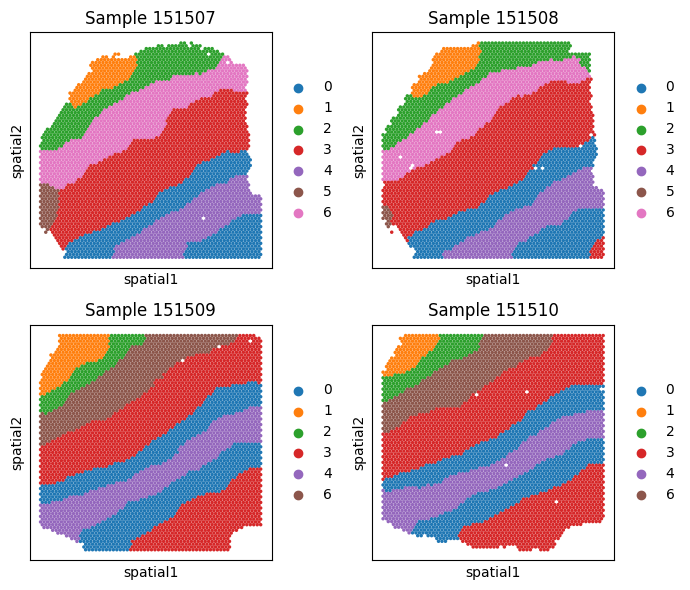

In [9]:
domain_outs_h5ad.obsm["spatial"] = domain_outs_h5ad.obs[["col", "row"]].to_numpy()

samples = domain_outs_h5ad.obs["sample_name"].unique()

fig, axes = plt.subplots(2, 2, figsize=(7, 6))

for sample, ax in zip(samples, axes.flatten()):
    adata_sub = domain_outs_h5ad[domain_outs_h5ad.obs["sample_name"] == sample].copy()

    sc.pl.embedding(
        adata_sub,
        basis="spatial",
        color="spatial_cluster_refined",
        size=25,
        ax=ax,
        show=False,
        title=f"Sample {sample}"
    )

plt.tight_layout()
plt.show()